In [11]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import seaborn as sns

# Configure plot for academic IEEE style
plt.rcParams.update({'font.size': 12, 'figure.figsize': (14, 7)})

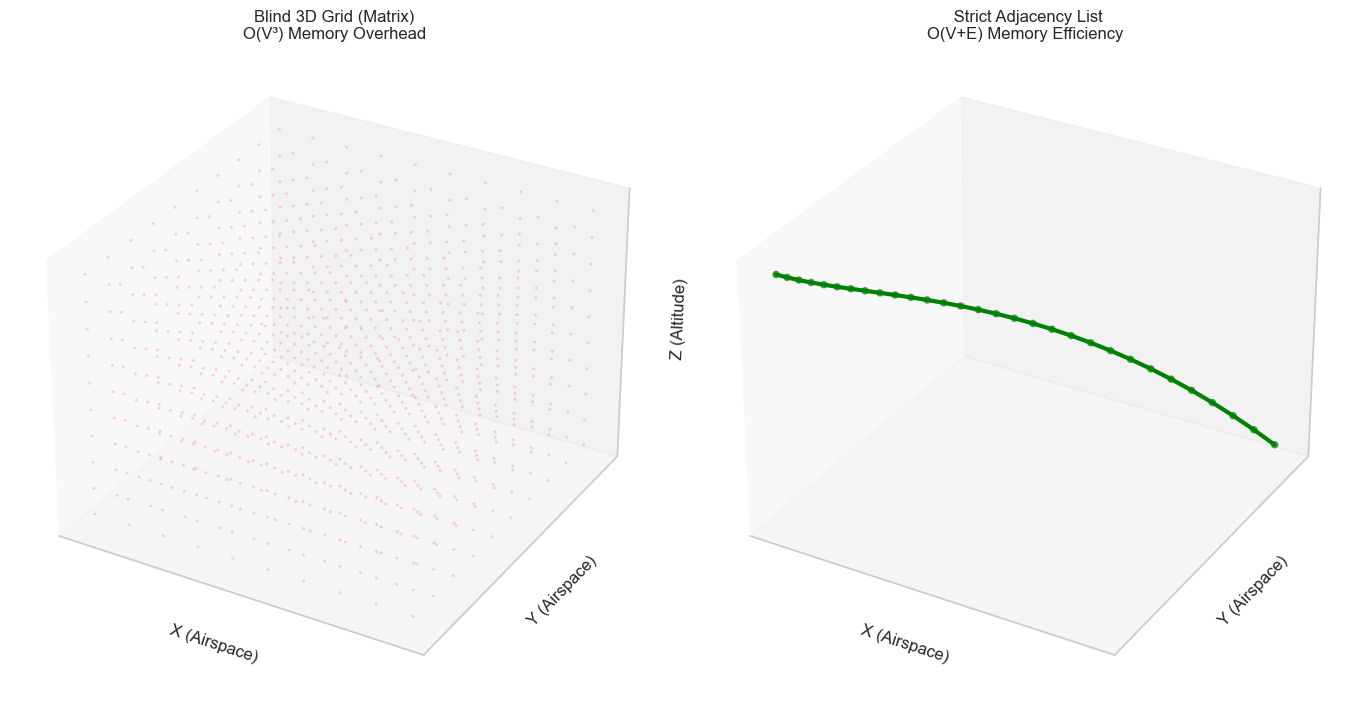

In [12]:
# 1. GENERATE DENSE GRID DATA (The "Bad" Way)
def generate_dense_grid(size=10):
    x, y, z = np.indices((size, size, size))
    # Fill the entire cube with "Used Memory" markers
    return x.flatten(), y.flatten(), z.flatten()

# 1. GENERATE DENSE GRID DATA (The "Bad" Way)
def generate_dense_grid(size=10):
    x, y, z = np.indices((size, size, size))
    # Fill the entire cube with "Used Memory" markers
    return x.flatten(), y.flatten(), z.flatten()

# 2. GENERATE SPARSE GRAPH DATA (The "Good" Way)
def generate_sparse_path(size=10):
    # Only store a minimal set of nodes for a sample trajectory
    # Start -> Target with a simple curve
    t = np.linspace(0, 1, 30)
    x = size * t
    y = size * (t**2) # A slight curve
    z = size * (1 - t**3)
    return x, y, z

# Setup the 3D plot with two subplots side-by-side
fig = plt.figure()
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# --- Panel 1: Blind 3D Matrix (Dijkstra/Dense) ---
size = 10
dx, dy, dz = generate_dense_grid(size)

# Visual: Every node is 'active' or 'stored'
ax1.scatter(dx, dy, dz, c='red', s=2, alpha=0.1) # Red dots for memory overload
ax1.set_title("Blind 3D Grid (Matrix)\nO(V³) Memory Overhead")
ax1.set_xlabel('X (Airspace)')
ax1.set_ylabel('Y (Airspace)')
ax1.set_zlabel('Z (Altitude)')
ax1.grid(True)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])

# --- Panel 2: Optimized Sparse Graph (A*/Strict Adjacency List) ---
sx, sy, sz = generate_sparse_path(size)

# Visual: Only store required edges and vertices
ax2.plot(sx, sy, sz, c='green', linewidth=3, label='Optimized Trajectory')
ax2.scatter(sx, sy, sz, c='green', s=20, alpha=0.6) # Highlight sparse nodes
# Add a few scattered obstacle cubes (gray)
# ax2.scatter(3, 4, 5, c='gray', s=200, marker='s')

ax2.set_title(" Strict Adjacency List\nO(V+E) Memory Efficiency")
ax2.set_xlabel('X (Airspace)')
ax2.set_ylabel('Y (Airspace)')
ax2.set_zlabel('Z (Altitude)')
ax2.grid(False)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_zticks([])

plt.tight_layout()
plt.savefig('../conference_material/graph_sparsity_comparison.png')
# plt.show()

In [13]:
# Load the verified data
df = pd.read_csv('../data/drone_navigation_results.csv')

# Set visual style for IEEE standards
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

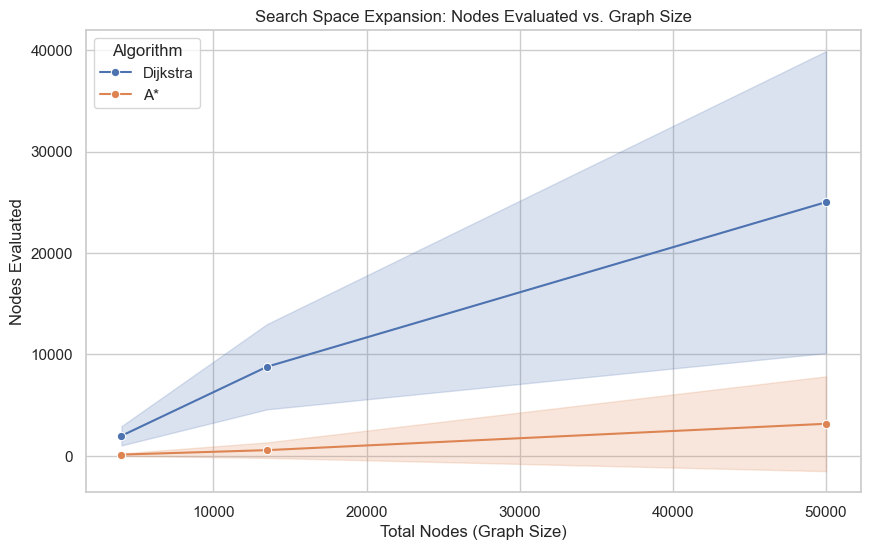

In [14]:
# 1. Fig 1: Search Space Expansion: Nodes Evaluated vs. Graph Size
plt.figure()
sns.lineplot(data=df, x='Graph_Nodes', y='Nodes_Evaluated', hue='Algorithm', marker='o', errorbar='sd')
plt.title('Search Space Expansion: Nodes Evaluated vs. Graph Size')
plt.ylabel('Nodes Evaluated')
plt.xlabel('Total Nodes (Graph Size)')
plt.savefig('../conference_material/search_space_efficiency.png')

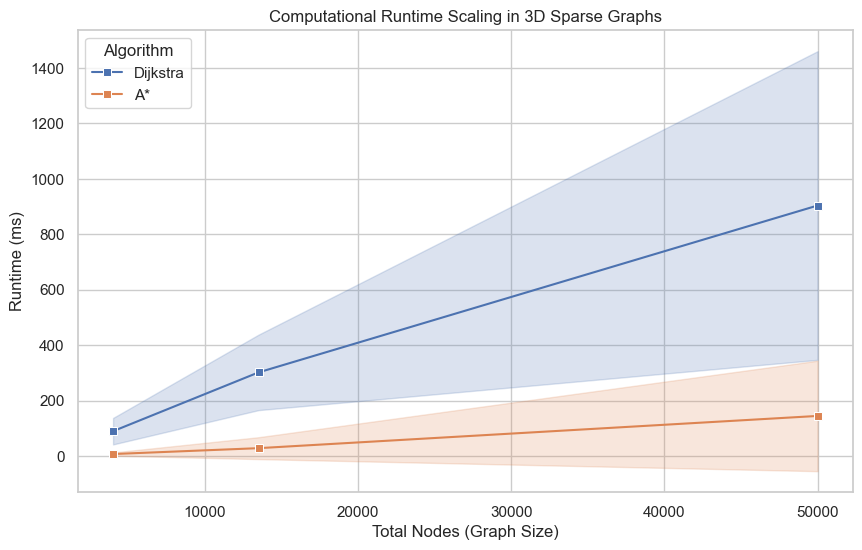

In [15]:
# 2. Fig 2: Computational Runtime Scaling in 3D Sparse Graphs
plt.figure()
sns.lineplot(data=df, x='Graph_Nodes', y='Runtime_ms', hue='Algorithm', marker='s', errorbar='sd')
plt.title('Computational Runtime Scaling in 3D Sparse Graphs')
plt.ylabel('Runtime (ms)')
plt.xlabel('Total Nodes (Graph Size)')
plt.savefig('../conference_material/runtime_comparison.png')

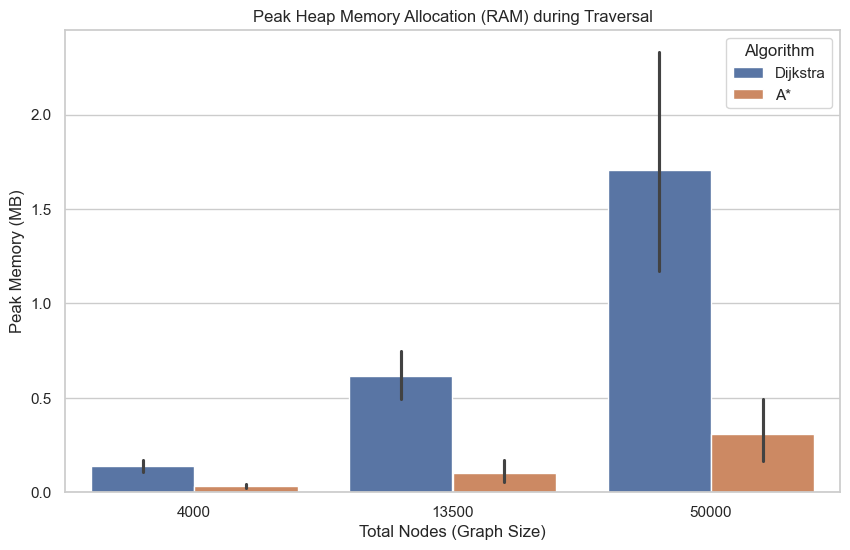

In [16]:
# 3. Fig 3: Peak Heap Memory Allocation (RAM) during Traversal
plt.figure()
sns.barplot(data=df, x='Graph_Nodes', y='Peak_Memory_MB', hue='Algorithm')
plt.title('Peak Heap Memory Allocation (RAM) during Traversal')
plt.ylabel('Peak Memory (MB)')
plt.xlabel('Total Nodes (Graph Size)')
plt.savefig('../conference_material/memory_bottleneck.png')

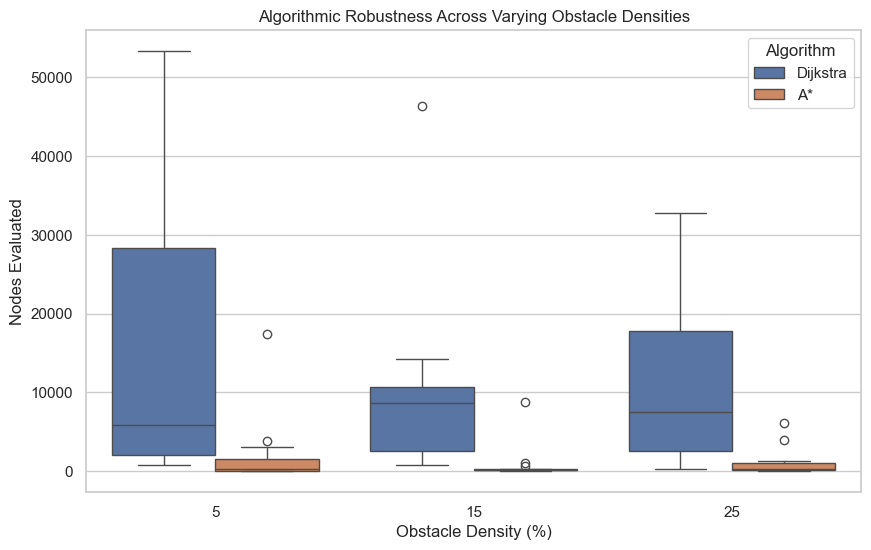

In [17]:
# 4. Fig 4: Algorithmic Robustness Across Varying Obstacle Densities
plt.figure()
sns.boxplot(data=df, x='Obstacle_Density_Pct', y='Nodes_Evaluated', hue='Algorithm')
plt.title('Algorithmic Robustness Across Varying Obstacle Densities')
plt.ylabel('Nodes Evaluated')
plt.xlabel('Obstacle Density (%)')
plt.savefig('../conference_material/density_impact.png')

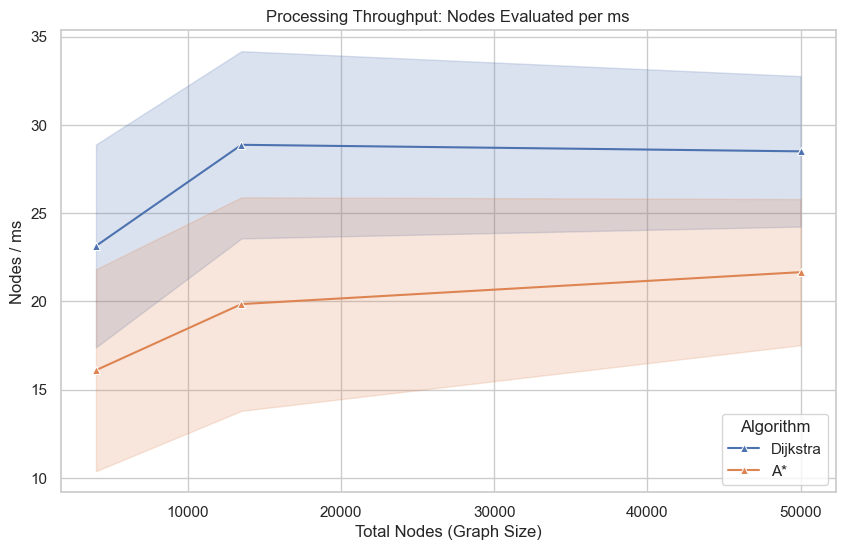

In [18]:
# 5. Fig 5: Processing Throughput: Nodes Evaluated per ms
df['Efficiency_Ratio'] = df['Nodes_Evaluated'] / df['Runtime_ms']
plt.figure()
sns.lineplot(data=df, x='Graph_Nodes', y='Efficiency_Ratio', hue='Algorithm', marker='^', errorbar='sd')
plt.title('Processing Throughput: Nodes Evaluated per ms')
plt.ylabel('Nodes / ms')
plt.xlabel('Total Nodes (Graph Size)')
plt.savefig('../conference_material/throughput.png')